### Задание №1:

Вы студент кафедры математики университета, изучающий статистику и её приложения. Вам было дано домашнее задание проанализировать успеваемость студентов по итогам экзаменационной сессии. Ваш преподаватель предложил рассчитать различные виды средних величин для лучшего понимания вариативности результатов среди учащихся.

Вашей задачей является написание программного кода на Python, который рассчитывает три вида средних значений — арифметическое, геометрическое и гармоническое — для массива оценок студентов. Массив оценок представлен следующим образом:

$$ students\_scores = \{75, 85, 90, 65, 70, 80, 95\} $$

Вам необходимо реализовать расчет всех указанных средних величин и вывести результат в консоль.

#### Входные данные:
- Список оценок студентов: `[75, 85, 90, 65, 70, 80, 95]`

#### Выходные данные:
- Арифметическое среднее.
- Геометрическое среднее.
- Гармоническое среднее.

Формат вывода должен выглядеть примерно так:

```
Средние величины:
Арифметическое среднее: XX.XX
Геометрическое среднее: YY.YY
Гармоническое среднее: ZZ.ZZ
```

При выполнении задания воспользуйтесь модулями `numpy` и `scipy`.

In [ ]:
import numpy as np
from scipy.stats import gmean, hmean

students_scores = np.array([75, 85, 90, 65, 70, 80, 95])

# Арифметическое среднее
arithmetic_mean = np.mean(students_scores)

# Геометрическое среднее
geometric_mean = gmean(students_scores)

# Гармоническое среднее
harmonic_mean = hmean(students_scores)

print("Средние величины:")
print(f"Арифметическое среднее: {arithmetic_mean:.2f}")
print(f"Геометрическое среднее: {geometric_mean:.2f}")
print(f"Гармоническое среднее: {harmonic_mean:.2f}")

Средние величины:
Арифметическое среднее: 80.00
Геометрическое среднее: 79.37
Гармоническое среднее: 78.74


### Задание №1 (решение 1.1)


In [1]:
import numpy as np
from scipy import stats

def analyze_scores(scores):
    """Рассчитывает три вида средних для массива оценок."""
    scores = np.array(scores, dtype=float)

    # Проверки
    if len(scores) == 0:
        raise ValueError("Массив оценок пуст")
    if np.any(scores <= 0):
        raise ValueError("Для геом. и гарм. среднего все значения должны быть > 0")

    arith = np.mean(scores)
    geo   = stats.gmean(scores)
    harm  = stats.hmean(scores)

    print("Средние величины:")
    print(f"Арифметическое среднее: {arith:.2f}")
    print(f"Геометрическое среднее: {geo:.2f}")
    print(f"Гармоническое среднее: {harm:.2f}")
    print(f"\nПроверка неравенства H ≤ G ≤ A: "
          f"{harm:.2f} ≤ {geo:.2f} ≤ {arith:.2f} → "
          f"{'✔' if harm <= geo <= arith else '✘'}")

    return arith, geo, harm


students_scores = [75, 85, 90, 65, 70, 80, 95]
analyze_scores(students_scores)

Средние величины:
Арифметическое среднее: 80.00
Геометрическое среднее: 79.37
Гармоническое среднее: 78.74

Проверка неравенства H ≤ G ≤ A: 78.74 ≤ 79.37 ≤ 80.00 → ✔


(np.float64(80.0),
 np.float64(79.36877359395028),
 np.float64(78.73502439370763))

-----------------------------------------------------------------------

### Задание №2:

**Цель:** Исследовать и сопоставить производительность двух популярных алгоритмов кластеризации — K-means и DBSCAN — на примере синтетически созданных данных.

**Описание:** Представьте себе ситуацию, когда исследовательская лаборатория проводит экспериментальные исследования свойств материалов. Учёные получили массив данных, представляющих характеристики образцов материала. Эти данные состоят из трёх хорошо выраженных категорий объектов, однако сами объекты смешаны и требуют разделения на отдельные группы для дальнейшего изучения.

**Задача:** Напишите программу на Python, реализующую следующую последовательность действий:

1. Сгенерируйте три независимых скопления точек (группы данных) с определёнными центрами и степенью разреженности.
2. Масштабируйте полученные данные для лучшей производительности алгоритмов.
3. Используя метод локтя (elbow method), найдите оптимальное количество кластеров для алгоритма K-means.
4. Проведите кластеризацию методом K-means с найденным оптимальным количеством кластеров.
5. Примените алгоритм DBSCAN для автоматической группировки данных без предварительного указания числа кластеров.
6. Отобразите графически результаты обеих методик, чтобы сравнить качество кластеризации.

**Требования к программе:**
- Исходные данные создаются случайным образом, сохраняя общий характер трех отдельных скоплений.
- Методы предварительной подготовки данных включают масштабирование и снижение размерности с помощью PCA.
- Оба метода кластеризации выполняются последовательно.
- Результат визуализируется с помощью Matplotlib.

**Пример входных данных:**  
Нет внешних источников данных, используются синтетические данные, созданные программой.

**Пример выходного результата:**  
Графики, показывающие кластеры, сформированные обоими методами, и вывод сообщений о проведённых операциях.

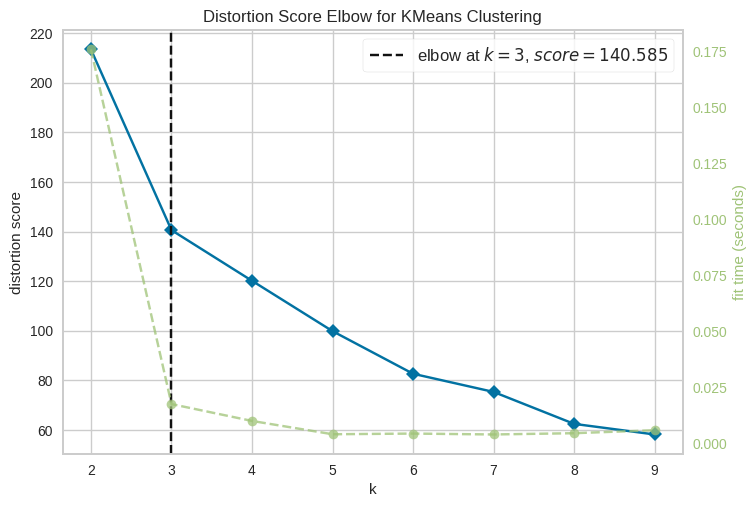

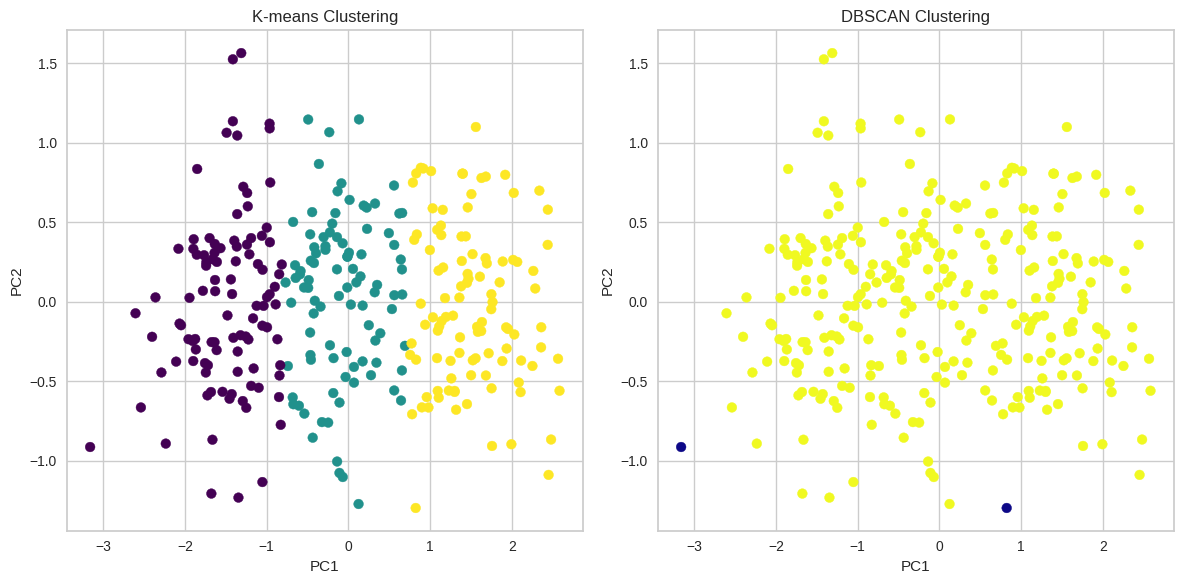

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

# 1. Создание синтетических данных
np.random.seed(42)

# Создадим три разных скопления точек
cluster1 = np.random.randn(100, 2) + [2, 2]
cluster2 = np.random.randn(100, 2) + [-2, -2]
cluster3 = np.random.randn(100, 2) + [0, 0]

# Объединяем данные
synthetic_data = np.vstack((cluster1, cluster2, cluster3))

# 2. Масштабируем данные
scaler = StandardScaler()
scaled_data = scaler.fit_transform(synthetic_data)

# Используем PCA для упрощения визуализации
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)

# 3. Нахождение оптимального числа кластеров для K-means
visualizer = KElbowVisualizer(KMeans(), k=(2,10))
visualizer.fit(reduced_data)
visualizer.show()

# 4. Кластеризация K-means
optimal_k = visualizer.elbow_value_
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(reduced_data)

# 5. Кластеризация с помощью DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(reduced_data)

# 6. Визуализация результатов
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels_kmeans, cmap='viridis')
axs[0].set_title('K-means Clustering')

axs[1].scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels_dbscan, cmap='plasma')
axs[1].set_title('DBSCAN Clustering')

for ax in axs.flat:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

### Задание №2 (Вариант 2.1)

ШАГ 1. Генерация данных
Размер данных: (600, 4)
Истинные метки: [0 1 2]
Распределение по классам: [200 200 200]

ШАГ 2. Масштабирование и PCA
После StandardScaler: mean=0.0000, std=1.0000
Объяснённая дисперсия PCA: 0.953 ([0.58772083 0.36554836])

ШАГ 3. Метод локтя
k=2: inertia=1059.24, silhouette=0.568
k=3: inertia=223.72, silhouette=0.740
k=4: inertia=199.83, silhouette=0.581
k=5: inertia=177.83, silhouette=0.414
k=6: inertia=158.35, silhouette=0.254
k=7: inertia=146.22, silhouette=0.254
k=8: inertia=137.13, silhouette=0.242
k=9: inertia=126.44, silhouette=0.240
k=10: inertia=120.21, silhouette=0.228

Оптимальное число кластеров (по silhouette): k = 3


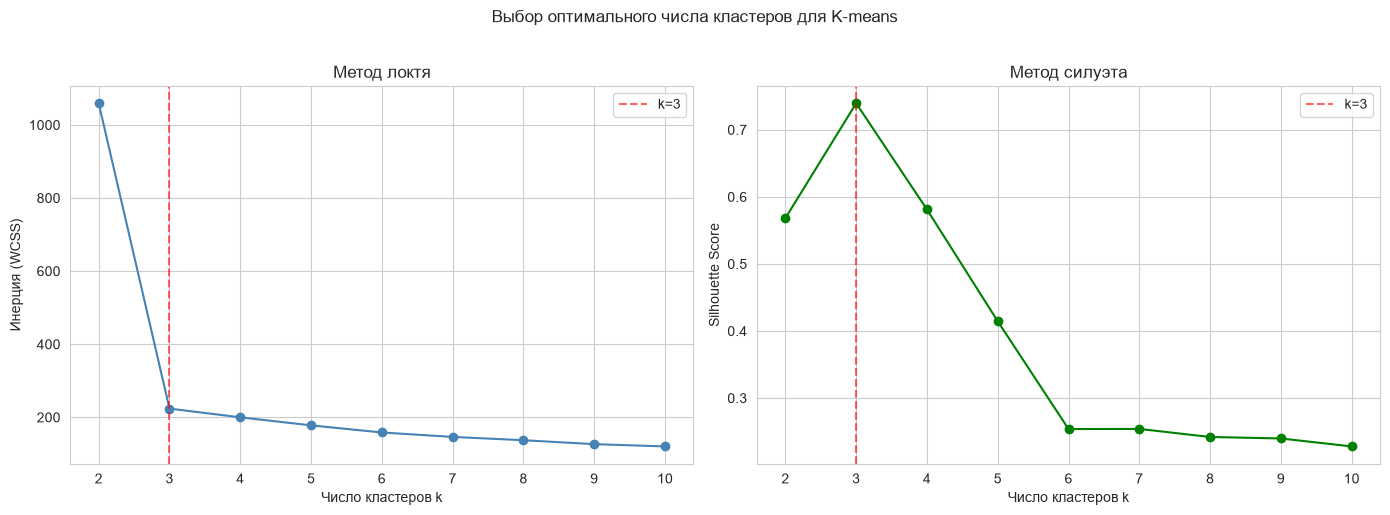


ШАГ 4. K-means
K-means (k=3):
  Инерция:        223.72
  Silhouette:     0.740
  Размеры кластеров: [200 200 200]

ШАГ 5. DBSCAN
Автоматически выбранный eps ≈ 0.402
DBSCAN (eps=0.402, min_samples=5):
  Найдено кластеров: 3
  Шумовых точек:     20 (3.3%)
  Silhouette (без шума): 0.748

ШАГ 6. Визуализация


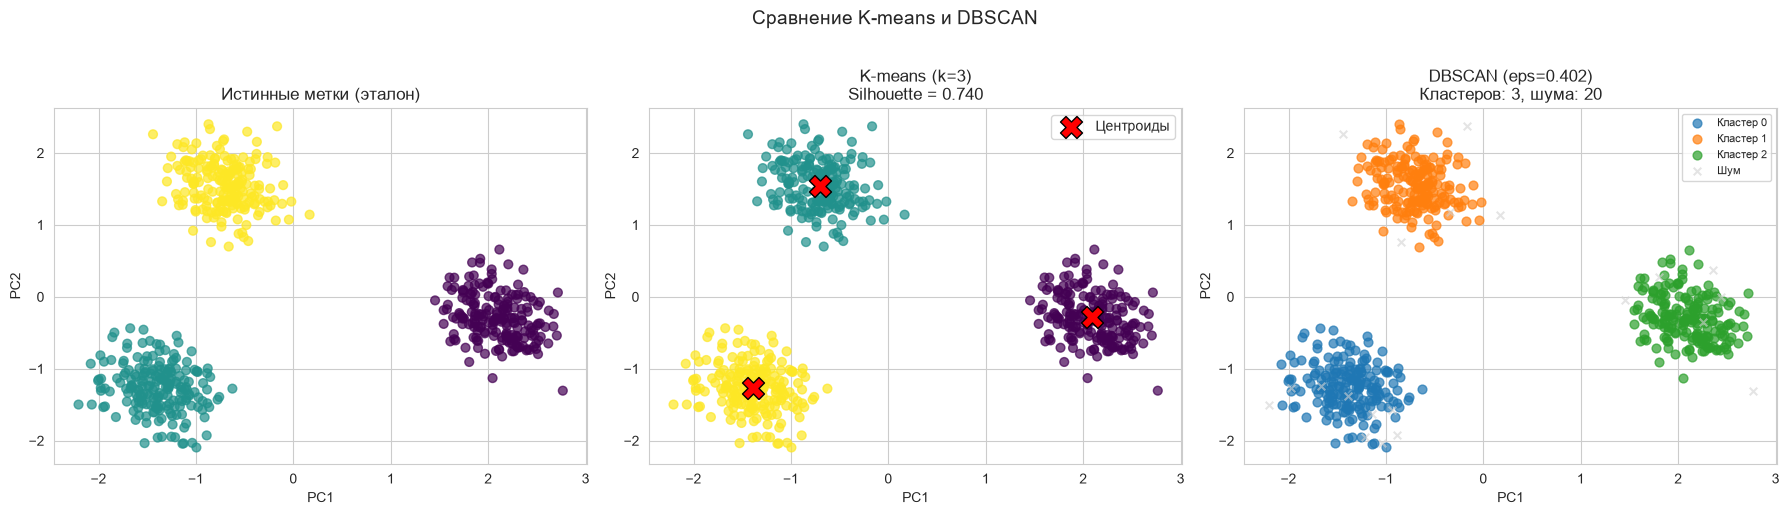


ИТОГОВАЯ СВОДКА

Метод        | Кластеров | Шум, %  | Silhouette
-------------|-----------|---------|------------
K-means      |     3     |    0    | 0.740
DBSCAN       |     3     |   3.3   | 0.748

Истинное число скоплений: 3
PCA объясняет 95.3% дисперсии



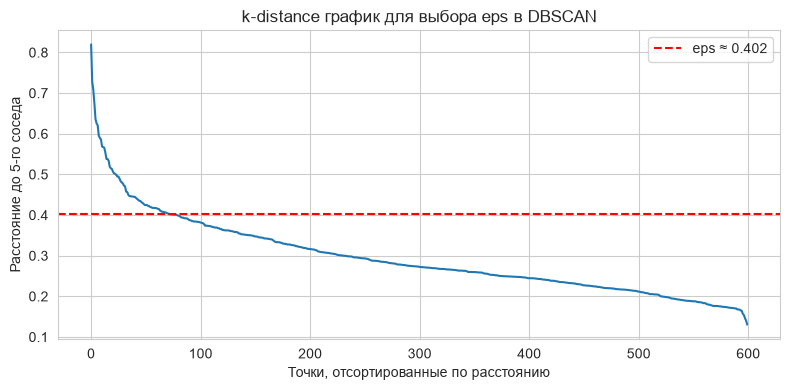

In [3]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
RANDOM_STATE = 42

# =============================================================
# 1. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ
# =============================================================
print("=" * 60)
print("ШАГ 1. Генерация данных")
print("=" * 60)

X, y_true = make_blobs(
    n_samples=600,
    centers=3,                 # три скопления
    cluster_std=1.4,           # степень разреженности
    n_features=4,              # 4 признака (чтобы потом применить PCA)
    random_state=RANDOM_STATE,
)

print(f"Размер данных: {X.shape}")
print(f"Истинные метки: {np.unique(y_true)}")
print(f"Распределение по классам: {np.bincount(y_true)}")

# =============================================================
# 2. МАСШТАБИРОВАНИЕ И СНИЖЕНИЕ РАЗМЕРНОСТИ
# =============================================================
print("\n" + "=" * 60)
print("ШАГ 2. Масштабирование и PCA")
print("=" * 60)

# Стандартизация: mean=0, std=1 для каждого признака
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"После StandardScaler: mean={X_scaled.mean():.4f}, "
      f"std={X_scaled.std():.4f}")

# PCA — снижение до 2 компонент для визуализации
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Объяснённая дисперсия PCA: "
      f"{pca.explained_variance_ratio_.sum():.3f} "
      f"({pca.explained_variance_ratio_})")

# =============================================================
# 3. МЕТОД ЛОКТЯ ДЛЯ K-MEANS
# =============================================================
print("\n" + "=" * 60)
print("ШАГ 3. Метод локтя")
print("=" * 60)

inertia = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))
    print(f"k={k}: inertia={km.inertia_:.2f}, "
          f"silhouette={silhouettes[-1]:.3f}")

# Определяем оптимальное k по максимальному silhouette
best_k = list(K_range)[int(np.argmax(silhouettes))]
print(f"\nОптимальное число кластеров (по silhouette): k = {best_k}")

# График метода локтя + силуэта
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertia, "-o", color="steelblue")
axes[0].set_xlabel("Число кластеров k")
axes[0].set_ylabel("Инерция (WCSS)")
axes[0].set_title("Метод локтя")
axes[0].axvline(best_k, color="red", ls="--", alpha=0.6, label=f"k={best_k}")
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, "-o", color="green")
axes[1].set_xlabel("Число кластеров k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Метод силуэта")
axes[1].axvline(best_k, color="red", ls="--", alpha=0.6, label=f"k={best_k}")
axes[1].legend()

plt.suptitle("Выбор оптимального числа кластеров для K-means", y=1.02)
plt.tight_layout()
plt.show()

# =============================================================
# 4. K-MEANS С ОПТИМАЛЬНЫМ K
# =============================================================
print("\n" + "=" * 60)
print("ШАГ 4. K-means")
print("=" * 60)

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, labels_km)
print(f"K-means (k={best_k}):")
print(f"  Инерция:        {kmeans.inertia_:.2f}")
print(f"  Silhouette:     {sil_km:.3f}")
print(f"  Размеры кластеров: {np.bincount(labels_km)}")

# =============================================================
# 5. DBSCAN
# =============================================================
print("\n" + "=" * 60)
print("ШАГ 5. DBSCAN")
print("=" * 60)

# Подбираем eps по k-distance графику (упрощённо — берём фиксированный)
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

# Автоматический выбор eps: «локоть» на k-distance графике
diffs = np.diff(k_distances)
eps_auto = k_distances[np.argmax(diffs) + 1]
print(f"Автоматически выбранный eps ≈ {eps_auto:.3f}")

dbscan = DBSCAN(eps=eps_auto, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = (labels_db == -1).sum()

print(f"DBSCAN (eps={eps_auto:.3f}, min_samples=5):")
print(f"  Найдено кластеров: {n_clusters_db}")
print(f"  Шумовых точек:     {n_noise_db} "
      f"({100 * n_noise_db / len(labels_db):.1f}%)")

# Silhouette для DBSCAN (только если >1 кластера и есть не-шум)
if n_clusters_db > 1:
    mask = labels_db != -1
    sil_db = silhouette_score(X_scaled[mask], labels_db[mask])
    print(f"  Silhouette (без шума): {sil_db:.3f}")
else:
    sil_db = None
    print("  Silhouette: невозможно (один кластер)")

# =============================================================
# 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# =============================================================
print("\n" + "=" * 60)
print("ШАГ 6. Визуализация")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Истинные метки ---
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true,
                cmap="viridis", s=40, alpha=0.7)
axes[0].set_title("Истинные метки (эталон)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# --- K-means ---
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km,
                cmap="viridis", s=40, alpha=0.7)
axes[1].scatter(
    pca.transform(kmeans.cluster_centers_)[:, 0],
    pca.transform(kmeans.cluster_centers_)[:, 1],
    c="red", marker="X", s=250, edgecolor="black",
    label="Центроиды", zorder=5,
)
axes[1].set_title(f"K-means (k={best_k})\n"
                  f"Silhouette = {sil_km:.3f}")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend()

# --- DBSCAN ---
unique_labels = set(labels_db)
palette = plt.cm.tab10
for lab in unique_labels:
    mask = labels_db == lab
    if lab == -1:
        # Шум — серые крестики
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        c="lightgray", marker="x", s=30,
                        label="Шум", alpha=0.6)
    else:
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        color=palette(lab % 10), s=40,
                        alpha=0.7, label=f"Кластер {lab}")

axes[2].set_title(f"DBSCAN (eps={eps_auto:.3f})\n"
                  f"Кластеров: {n_clusters_db}, "
                  f"шума: {n_noise_db}")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
axes[2].legend(fontsize=8)

plt.suptitle("Сравнение K-means и DBSCAN", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# =============================================================
# 7. ИТОГОВАЯ СВОДКА
# =============================================================
print("\n" + "=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)

summary = f"""
Метод        | Кластеров | Шум, %  | Silhouette
-------------|-----------|---------|------------
K-means      | {best_k:^9} | {0:^7} | {sil_km:.3f}
DBSCAN       | {n_clusters_db:^9} | {100*n_noise_db/len(labels_db):^7.1f} | \
{'-' if sil_db is None else f'{sil_db:.3f}'}

Истинное число скоплений: 3
PCA объясняет {pca.explained_variance_ratio_.sum():.1%} дисперсии
"""
print(summary)

# =============================================================
# 8. K-DISTANCE ГРАФИК (для обоснования выбора eps)
# =============================================================
plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.axhline(eps_auto, color="red", ls="--",
            label=f"eps ≈ {eps_auto:.3f}")
plt.xlabel("Точки, отсортированные по расстоянию")
plt.ylabel("Расстояние до 5-го соседа")
plt.title("k-distance график для выбора eps в DBSCAN")
plt.legend()
plt.tight_layout()
plt.show()

-------------------------------------------------------------------

### Задание №3:

Представьте себя аналитиком крупной сети магазинов электронной техники. Руководство заинтересовано в оценке эффективности рекламы и хочет понять, насколько вероятно, что определенное количество посетителей совершит покупку после посещения сайта компании. Для этого предлагается рассмотреть две классические теории вероятностных процессов: биноминальный и пуассоновский подходы.

#### Цель задания:
Рассчитать вероятность того, что ровно $ k $ посетителей совершат покупку, учитывая известную общую посещаемость сайта и среднюю вероятность совершения покупки одним посетителем.

#### Входные данные:
- Общая посещаемость сайта за определенный период: $ N = 1000 $
- Средняя вероятность покупки одного посетителя: $ p = 0.05 $
- Число интересующих покупок: $ k = 50 $

#### Ваши задачи:
1. Рассчитайте вероятность события (ровно $ k $ покупок) с помощью биноминального распределения.
2. Повторите расчёт с использованием распределения Пуассона.
3. Выведите обе вероятности с точностью до четырёх знаков после запятой.

#### Критерии оценки:
- Правильно использованные формулы и методики расчёта.
- Ясность представления конечного результата.
- Соблюдение формата вывода согласно примерам ниже.

#### Формат вывода:
```
Биноминальное распределение: P(k)=XXX.XXXX
Пуассон распределение: P(k)=YYY.YYYY
```

Используйте библиотеки `scipy.stats` для выполнения расчетов.

In [ ]:
from scipy.stats import binom, poisson

# Параметры эксперимента (N попыток, вероятность успеха)
N = 1000  # Количество посетителей
p = 0.05  # Вероятность покупки каждым посетителем

# Рассчёт вероятности события с помощью биноминального распределения
k = 50  # Интересующее число покупок
binomial_prob = binom.pmf(k, N, p)
print(f"Биноминальное распределение: P({k})={binomial_prob:.4f}")

# Оцениваем вероятность аналогичным образом с помощью распределения Пуассона
lambda_val = N * p
poisson_prob = poisson.pmf(k, lambda_val)
print(f"Пуассон распределение: P({k})={poisson_prob:.4f}")

Биноминальное распределение: P(50)=0.0578
Пуассон распределение: P(50)=0.0563


-------------------------------------------------------------------

### Задание №4:

Предположим, вы работаете научным сотрудником лаборатории по исследованию климатических изменений. Ваша команда собрала ряд наблюдений температуры воздуха в определенной местности за короткий временной отрезок. Поскольку измерительные приборы имеют погрешности, вы хотите построить доверительный интервал для истинного среднего значения температуры, основываясь на имеющихся наблюдениях.

#### Ваше задание состоит из следующих этапов:

1. Сгенерируйте выборку размером $ N = 100 $, соответствующую нормальной случайной величине с известным средним значением $\mu = 10$ и стандартным отклонением $\sigma = 2$.

2. Определите границы доверительного интервала для истинного среднего значения с уровнем достоверности $95\%$, используя метод, основанный на $t$-распределении Стъюдента.

3. Изобразите гистограмму вашей выборочной совокупности, наложив на неё вертикальные линии, обозначающие нижнюю и верхнюю границу построенного доверительного интервала.

4. Выведите в консоль доверительный интервал, округлив результаты до второго знака после запятой.

#### Примечания:
- Уровень доверия выбирается равным $95\%$. То есть искомый доверительный интервал должен охватывать приблизительно $95\%$ возможных значений истинного среднего.
- Используйте модуль `matplotlib` для визуализации, а для расчета границ доверительного интервала пользуйтесь модулем `scipy.stats`.

#### Пример выхода:
```
Доверительный интервал для истинного среднего (95% уровень доверия): [XX.XX, YY.YY]
```

Также программа должна выводить график с гистограммой выборочных данных и границами доверительного интервала.


Доверительный интервал для истинного среднего (95.0% уровень доверия): [9.45, 10.24]



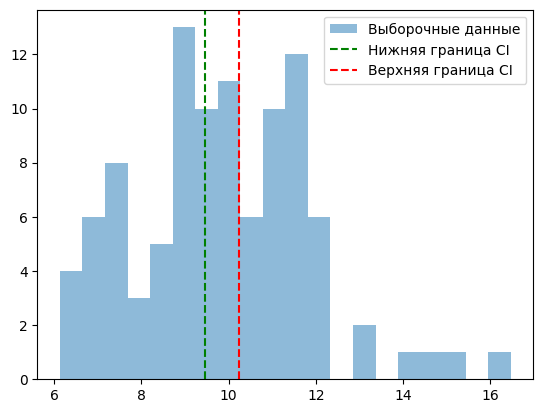

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import t

sample_size = 100
mu_true = 10
sigma_true = 2
confidence_level = 0.95

# Генерируем выборку из нормального распределения
random_sample = np.random.normal(mu_true, sigma_true, sample_size)

# Вычисляем оценки среднего и стандартного отклонения
sample_mean = random_sample.mean()
sample_std = random_sample.std(ddof=1)

# Определяем критические точки для доверительного интервала
degrees_of_freedom = len(random_sample) - 1
critical_point = t.ppf((1 + confidence_level)/2, degrees_of_freedom)
margin_error = critical_point * (sample_std / np.sqrt(sample_size))

lower_bound = sample_mean - margin_error
upper_bound = sample_mean + margin_error

print(f"\nДоверительный интервал для истинного среднего ({confidence_level*100}% уровень доверия): "
      f"[{lower_bound:.2f}, {upper_bound:.2f}]\n")

plt.hist(random_sample, bins=20, alpha=0.5, label='Выборочные данные')
plt.axvline(lower_bound, color="green", linestyle="--", label=f'Нижняя граница CI')
plt.axvline(upper_bound, color="red", linestyle="--", label=f'Верхняя граница CI')
plt.legend()
plt.show()

-------------------------------------------------

### Задание №5:

Студентам курса "Анализ данных и статистика" предстоит изучить особенности распределения вероятностей, в частности, понятие полимодальных распределений и способы их анализа.

#### Постановка задачи:
Необходимо исследовать свойства полимодального распределения, которое характеризуется наличием нескольких максимумов плотности вероятности (мод). Полимодальность возникает, когда исследуемые данные содержат несколько существенно отличающихся друг от друга подгрупп.

#### Техническое задание:
Напишите скрипт на Python, который решает следующие задачи:

1. Сформируйте полимодальное распределение, состоящее из двух нормально распределённых групп с различными средними значениями ($\mu_1 = -2$, $\mu_2 = +2$), одинаковой дисперсией ($\sigma^2 = 1$) и одинаковым объёмом выборки (по 100 элементов в каждой группе).

2. Постройте плотность распределения вероятностей (kernel density estimation, KDE) для вашего распределения с заполненным фоном и утолщённой границей линий. Задайте подходящие заголовки осей и название графика.

3. Оцените стандартное отклонение полученного полимодального распределения и выведите его в терминал с точностью до двух десятичных знаков.

#### Примечания:
- Используйте пакет Seaborn для построения графика плотности.
- Программный код должен аккуратно структурирован и сопровождаться комментариями там, где это уместно.

#### Пример ожидаемого вывода:
```
Стандартное отклонение полимодального распределения: XX.XX
```

Результатом выполнения задания станет диаграмма, отражающая полимодальную природу данных, и числовая характеристика их рассеивания (стандартное отклонение).

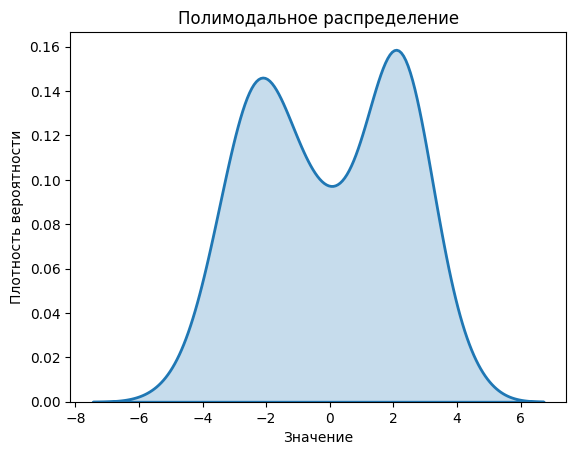

Стандартное отклонение полимодального распределения: 2.29


In [ ]:
import seaborn as sns

# Создаем многорежимное распределение (полимодальность)
multimodal_data = np.concatenate((
    np.random.normal(loc=-2, scale=1, size=100),
    np.random.normal(loc=+2, scale=1, size=100)))

sns.kdeplot(multimodal_data, fill=True, linewidth=2)
plt.title('Полимодальное распределение')
plt.xlabel('Значение')
plt.ylabel('Плотность вероятности')
plt.show()

# Анализируем разброс данных
std_dev = multimodal_data.std()
print(f"Стандартное отклонение полимодального распределения: {std_dev:.2f}")